In [0]:
%pip install torch torchvision ultralytics opencv-python pyyaml

In [0]:
import glob
import os
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1) METADATA GLOB PATTERNS
meta_patterns = [
    "/xxx/Tol/Final Metadata/Final_metadata_Tol_Ch01_20240424_054840_20240424_104652.csv/part-*.csv",
    "/xxx/Hou/Final Metadata/Final_metadata_Hou_Ch01_20241003_104729_20241003_235954.csv/part-*.csv",
    "/xxx/Eem/Final Metadata/Final_metadata_Eem_Ch04_20240619_060343_20240619_235951.csv/part-*.csv",
    "/xxx/Tol2/Final Metadata/Final_metadata_Tol2_0611_060936_131254.csv/part-*.csv",
    "/xxx/Tol2/Final Metadata/Final_metadata_Tol2_ch01_0611_133427_235956.csv/part-*.csv",
    "/xxx/Voor/Final Metadata/Final_metadata_Voor_ch01_1129_123835_231930.csv/part-*.csv"
]

# Expand all wildcards
meta_paths = []
for pat in meta_patterns:
    found = glob.glob(pat)
    if not found:
        raise FileNotFoundError(f"No files matched: {pat}")
    meta_paths.extend(found)

print("Found metadata files:", meta_paths)

# Read & concatenate
dfs = [pd.read_csv(p) for p in meta_paths]
df  = pd.concat(dfs, ignore_index=True)

# 2) FIX EMBEDDING PATHS for torch.load
#    change "dbfs:/mnt/…" → "/dbfs/mnt/…"
df["embedding_path"] = (
    df["Embeddings directory"]
      .str.replace("^dbfs:", "/dbfs", regex=True)
)

# 3) BALANCE CLASSES
active_df    = df[df["Final Label"] == "Active Playing"]
n_active     = len(active_df)
nonactive_df = df[df["Final Label"] == "Non Active Playing"].sample(n=n_active, random_state=42)
notplay_df   = df[df["Final Label"] == "Not Playing"].sample(n=n_active, random_state=42)

df_bal = pd.concat([active_df, nonactive_df, notplay_df], ignore_index=True)
df_bal = df_bal.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

# 4) LABEL ENCODING
label2idx = {"Active Playing":0, "Non Active Playing":1, "Not Playing":2}
df_bal["label"] = df_bal["Final Label"].map(label2idx)
num_classes   = len(label2idx)

# 5) STRATIFIED SPLIT 70/15/15
train_df, tmp_df = train_test_split(
    df_bal, test_size=0.30, stratify=df_bal["label"], random_state=42
)
val_df, test_df = train_test_split(
    tmp_df, test_size=0.50, stratify=tmp_df["label"], random_state=42
)

print(f"Splits → train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")

# 6) PYTORCH DATASET
class EmbeddingDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        emb   = torch.load(row["embedding_path"]).float()
        lbl   = torch.tensor(row["label"], dtype=torch.long)
        return emb, lbl

batch_size = 64
train_loader = DataLoader(EmbeddingDataset(train_df), batch_size=batch_size, shuffle=True,  num_workers=4)
val_loader   = DataLoader(EmbeddingDataset(val_df),   batch_size=batch_size, shuffle=False, num_workers=4)
test_loader  = DataLoader(EmbeddingDataset(test_df),  batch_size=batch_size, shuffle=False, num_workers=4)

# 7) MLP DEFINITION
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dims=[512,256], num_classes=3, dropout=0.5):
        super().__init__()
        layers, prev = [], input_dim
        for h in hidden_dims:
            layers += [ nn.Linear(prev,h), nn.ReLU(inplace=True), nn.Dropout(dropout) ]
            prev = h
        layers += [ nn.Linear(prev, num_classes) ]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

# 8) INSTANTIATE MODEL, LOSS & OPTIMIZER
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# infer embedding size
sample_emb, _ = next(iter(train_loader))
input_dim = sample_emb.shape[1]

model     = MLPClassifier(input_dim=input_dim, hidden_dims=[512,256],
                          num_classes=num_classes, dropout=0.5).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# 9) TRAIN / VAL LOOPS WITH EARLY STOPPING
def run_epoch(loader, train=True):
    if train:
        model.train()
    else:
        model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    for X,y in loader:
        X, y = X.to(device), y.to(device)
        logits = model(X)
        loss   = criterion(logits, y)
        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * X.size(0)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    return total_loss/len(loader.dataset), acc, all_labels, all_preds

best_val_loss, epochs_no_improve, patience = float('inf'), 0, 5
for epoch in range(1, 51):
    tr_loss, tr_acc, _, _ = run_epoch(train_loader, train=True)
    val_loss, val_acc, _, _ = run_epoch(val_loader, train=False)
    print(f"Epoch {epoch:02d} – train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
          f"val loss {val_loss:.4f}, acc {val_acc:.3f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_mlp.pt")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping.")
            break

# 10) TEST EVALUATION
model.load_state_dict(torch.load("best_mlp.pt"))
_, test_acc, y_true, y_pred = run_epoch(test_loader, train=False)
print(f"\nTest Accuracy: {test_acc:.3f}\n")
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=label2idx.keys()))

# 11) CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1)[:,None]
print("Confusion Matrix (% of true):")
print(np.round(cm_norm * 100, 1))
# 

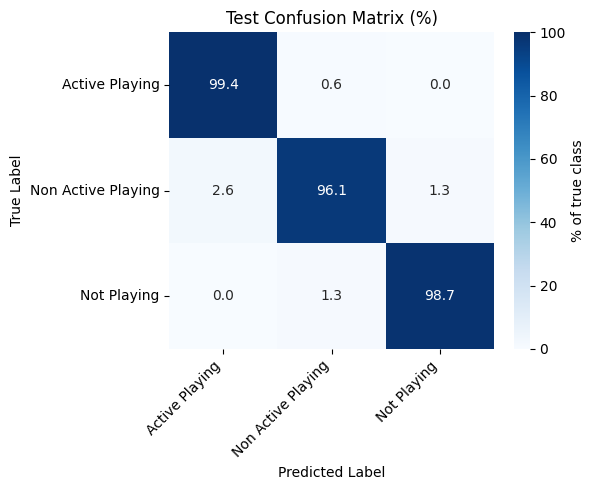

In [0]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(6, 5))
ax = sns.heatmap(
        cm_percent,
        annot=True, fmt='.1f',           # show one decimal place
        cmap='Blues',                    # colour map
        vmin=0, vmax=100,                # always 0-100 %
        cbar_kws={'label': '% of true class'}
     )

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticklabels(class_names, rotation=0)
ax.set_title('Test Confusion Matrix (%)')
plt.tight_layout()
plt.show()

Embedding Visualization

Using 6192 total points (2064 per class)


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7260bdb2afc0>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.12/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.12/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.12/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.12/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'split'


Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

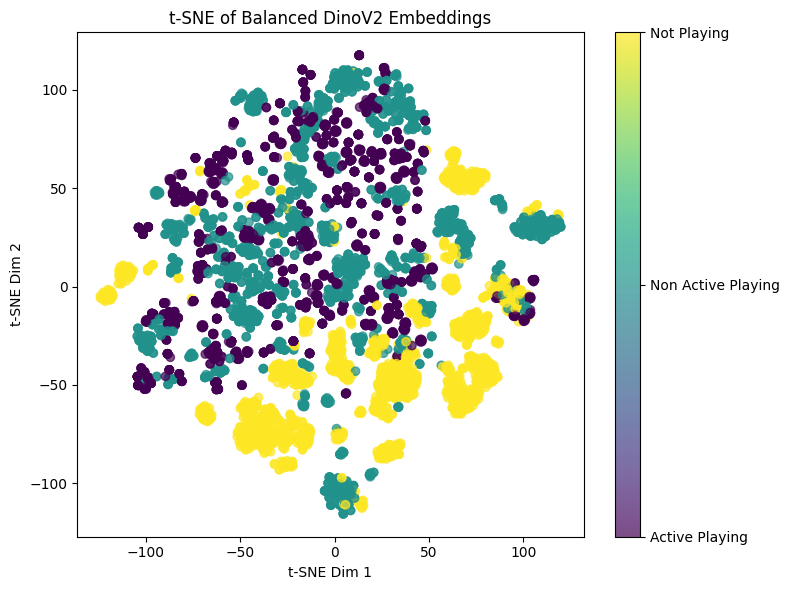

In [0]:
import glob
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 1) GLOB & LOAD METADATA CSVs
meta_patterns = [
    "/xxx/Tol/Final Metadata/Final_metadata_Tol_Ch01_20240424_054840_20240424_104652.csv/part-*.csv",
    "/xxx/Hou/Final Metadata/Final_metadata_Hou_Ch01_20241003_104729_20241003_235954.csv/part-*.csv",
    "/xxx/Eem/Final Metadata/Final_metadata_Eem_Ch04_20240619_060343_20240619_235951.csv/part-*.csv",
    "/xxx/Tol2/Final Metadata/Final_metadata_Tol2_0611_060936_131254.csv/part-*.csv",
    "/xxx/Tol2/Final Metadata/Final_metadata_Tol2_ch01_0611_133427_235956.csv/part-*.csv",
    "/xxx/Voor/Final Metadata/Final_metadata_Voor_ch01_1129_123835_231930.csv/part-*.csv"
]

meta_paths = []
for pat in meta_patterns:
    files = glob.glob(pat)
    if not files:
        print(f"Warning: no files found for pattern {pat}")
    meta_paths.extend(files)

df = pd.concat([pd.read_csv(p) for p in meta_paths], ignore_index=True)

# 2) PREPARE EMBEDDING PATHS & LABELS
df["embedding_path"] = df["Embeddings directory"].str.replace("^dbfs:", "/dbfs", regex=True)
label2idx = {"Active Playing":0, "Non Active Playing":1, "Not Playing":2}
df["label_idx"] = df["Final Label"].map(label2idx)

# 3) BALANCED SUBSAMPLING
# count Active Playing
n_active = (df["label_idx"] == 0).sum()

# sample same number from other two
non_act = df[df["label_idx"] == 1].sample(n=n_active, random_state=42)
not_play = df[df["label_idx"] == 2].sample(n=n_active, random_state=42)
active = df[df["label_idx"] == 0]

df_bal = pd.concat([active, non_act, not_play]).sample(frac=1, random_state=42).reset_index(drop=True)

# 4) LOAD EMBEDDINGS & LABELS
embs = []
lbls = []
for _, row in df_bal.iterrows():
    emb = torch.load(row["embedding_path"]).numpy()
    embs.append(emb)
    lbls.append(row["label_idx"])

embeddings_np = np.stack(embs, axis=0)
labels_np     = np.array(lbls)

print(f"Using {embeddings_np.shape[0]} total points ({n_active} per class)")

# 5) RUN t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42
)
emb_2d = tsne.fit_transform(embeddings_np)

# 6) PLOT
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    emb_2d[:,0], emb_2d[:,1],
    c=labels_np, cmap="viridis", alpha=0.7
)
plt.title("t-SNE of Balanced DinoV2 Embeddings")
plt.xlabel("t-SNE Dim 1")
plt.ylabel("t-SNE Dim 2")
cbar = plt.colorbar(scatter, ticks=[0,1,2])
cbar.ax.set_yticklabels(["Active Playing","Non Active Playing","Not Playing"])
plt.tight_layout()
plt.show()